In [1]:
import pandas as pd
import numpy as np


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier


from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv("Sleep_health_and_lifestyle_dataset (1).csv")
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [3]:
df["Sleep Disorder"] = df["Sleep Disorder"].fillna("None")

In [5]:
if "Person ID" in df.columns:
       df.drop(columns=["Person ID"], inplace=True)

In [6]:
df["BMI Category"] = df["BMI Category"].replace({"Normal Weight": "Normal"})


# Split Blood Pressure
if "Blood Pressure" in df.columns:
       df[["Systolic_BP", "Diastolic_BP"]] = df["Blood Pressure"].str.split('/', expand=True).astype(int)
       df.drop(columns=["Blood Pressure"], inplace=True)

In [7]:
X = df.drop(columns=["Sleep Disorder"])
y = df["Sleep Disorder"]

In [8]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)


print("Classes:", le.classes_)

Classes: ['Insomnia' 'None' 'Sleep Apnea']


In [ ]:
categorical_cols = X.select_dtypes(include="object").columns
numerical_cols = X.select_dtypes(exclude="object").columns


preprocessor = ColumnTransformer(
transformers=[
("num", StandardScaler(), numerical_cols),
("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)]
)

In [10]:
rf_model = Pipeline([
("preprocessor", preprocessor),
("classifier", RandomForestClassifier(
n_estimators=200,
random_state=42
))
])

In [11]:
xgb_model = Pipeline([
("preprocessor", preprocessor),
("classifier", XGBClassifier(
n_estimators=200,
learning_rate=0.05,
max_depth=5,
eval_metric='mlogloss',
random_state=42
))
])

In [12]:
voting_clf = VotingClassifier(
estimators=[
('rf', rf_model),
('xgb', xgb_model)
],
voting='soft'
)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
X, y_encoded,
test_size=0.2,
stratify=y_encoded,
random_state=42
)

In [14]:
voting_clf.fit(X_train, y_train)

,estimators,"[('rf', ...), ('xgb', ...)]"
,voting,'soft'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None


In [15]:
y_pred = voting_clf.predict(X_test)


acc = accuracy_score(y_test, y_pred)
print(f"Final Accuracy: {acc*100:.2f}%")


print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))


print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Final Accuracy: 96.00%

Classification Report:

              precision    recall  f1-score   support

    Insomnia       0.88      0.93      0.90        15
        None       1.00      0.98      0.99        44
 Sleep Apnea       0.94      0.94      0.94        16

    accuracy                           0.96        75
   macro avg       0.94      0.95      0.94        75
weighted avg       0.96      0.96      0.96        75

Confusion Matrix:

[[14  0  1]
 [ 1 43  0]
 [ 1  0 15]]


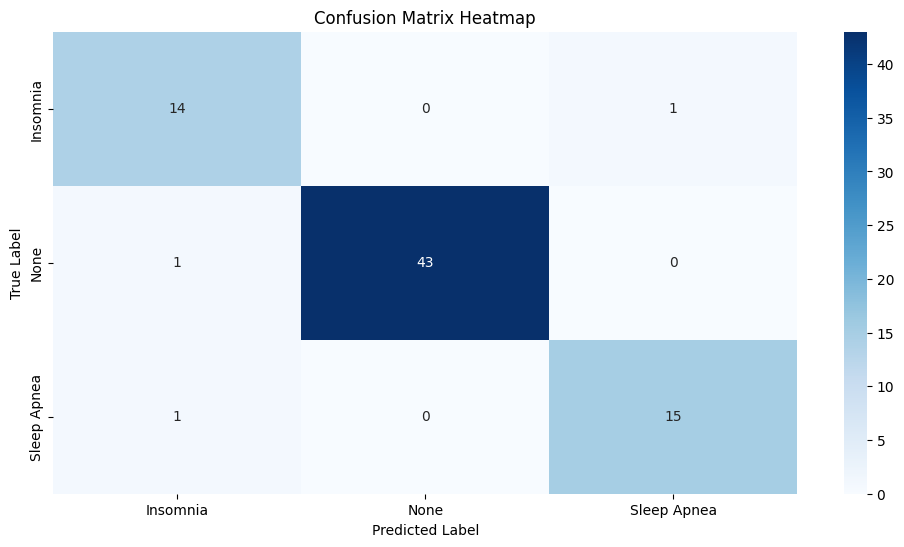

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns


cm = confusion_matrix(y_test, y_pred)


plt.figure(figsize=(12,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
xticklabels=le.classes_,
yticklabels=le.classes_)


plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.show()